In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc file csv
df = pd.read_csv(r"C:\Users\Dell\Documents\GitHub\DS111\Data\Gold\Gold_1.csv")

# Xem 5 dòng đầu để kiểm tra
print("Dữ liệu đầu vào:")
display(df.head())

Dữ liệu đầu vào:


,Country_Code,Year,Country_Name,AHS_Weighted_Average_Percent,MFN_Weighted_Average_Percent,AHS_Duty_Free_Tariff_Lines_Share_Percent,has_RCA,has_Country_Growth,cc_rank,pv_rank,rl_rank,va_rank,Log_Export,Log_Import,Tariff_Gap,Country_Growth_Percent,Effective_Tariff
0,ABW,2004,Aruba,3.31,5.69,56.76,1,1,85.2,80.6,80.8,73.1,14.770925,14.745080,2.38,1.73,1.431244
1,ABW,2005,Aruba,2.22,5.78,47.31,1,1,88.3,96.1,78.0,85.6,14.960064,15.217246,3.56,8.43,1.169718
2,ABW,2006,Aruba,2.76,6.11,39.90,1,1,88.3,96.1,72.7,80.3,15.051433,15.286031,3.35,0.55,1.658760
3,ABW,2007,Aruba,2.39,5.91,52.70,1,1,88.3,96.6,75.1,78.4,14.917213,15.362467,3.52,3.42,1.130470
4,ABW,2008,Aruba,2.78,7.56,47.17,1,1,87.4,96.2,76.4,79.3,14.880180,15.537949,4.78,-0.06,1.468674


# 1. Thống kê mô tả (So sánh trung bình)

In [2]:
# Tính trung bình điểm số WGI cho 2 nhóm: Có RCA (1) và Không RCA (0)
# Danh sách các cột chỉ báo chính trị (Control Corruption, Political Stability, Rule of Law, Voice)
wgi_cols = ['cc_rank', 'pv_rank', 'rl_rank', 'va_rank']

# Groupby theo 'has_RCA' và tính trung bình
compare_table = df.groupby('has_RCA')[wgi_cols].mean()

print("Bảng so sánh trung bình điểm xếp hạng WGI:")
display(compare_table)

Bảng so sánh trung bình điểm xếp hạng WGI:


,cc_rank,pv_rank,rl_rank,va_rank
has_RCA,,,,
0,39.023288,41.249664,39.292454,39.549779
1,48.371675,45.871928,47.533726,47.466525



Kết quả thống kê mô tả cho thấy sự phân hóa rõ rệt về chất lượng thể chế giữa hai nhóm quốc gia:
* **Chênh lệch điểm số:** Nhóm quốc gia có lợi thế so sánh (**has_RCA = 1**) sở hữu điểm trung bình các chỉ số WGI cao hơn hẳn nhóm không có lợi thế.
* **Đối chiếu lý thuyết:** Điều này cung cấp bằng chứng thực nghiệm ủng hộ luận điểm của **Levchenko (2007)**, cho rằng chất lượng thể chế (đặc biệt là Pháp quyền và Kiểm soát tham nhũng) đóng vai trò như một nguồn lực sản xuất, giúp quốc gia hình thành lợi thế so sánh trong các ngành hàng phức tạp.

# 2. Trực quan hóa bằng Boxplot

C:\Users\Dell\AppData\Local\Temp\ipykernel_8736\1464022319.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='has_RCA', y='pv_rank', palette='Set2')


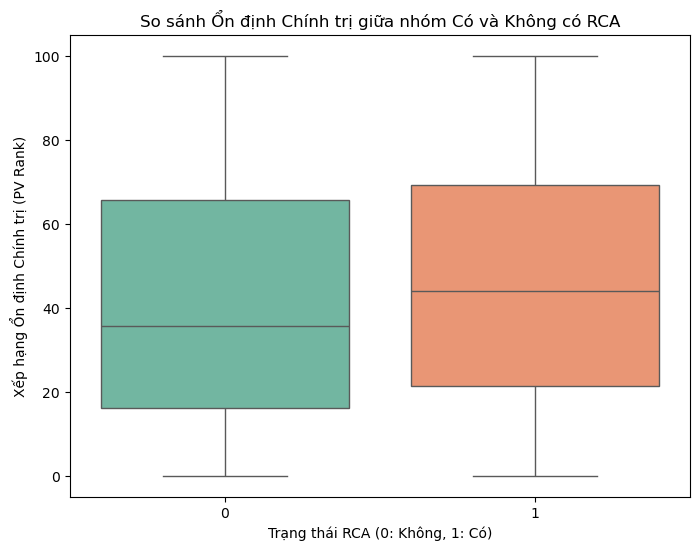

In [3]:
# Vẽ Boxplot so sánh phân phối điểm Ổn định chính trị (pv_rank)
plt.figure(figsize=(8, 6))

# Vẽ biểu đồ hộp
sns.boxplot(data=df, x='has_RCA', y='pv_rank', palette='Set2')

plt.title('So sánh Ổn định Chính trị giữa nhóm Có và Không có RCA')
plt.xlabel('Trạng thái RCA (0: Không, 1: Có)')
plt.ylabel('Xếp hạng Ổn định Chính trị (PV Rank)')
plt.show()

Biểu đồ Boxplot minh họa phân phối chỉ số Ổn định Chính trị (PV) theo trạng thái RCA:
* **Median Gap:** Đường trung vị của nhóm có RCA nằm ở mức xếp hạng cao hơn đáng kể (khoảng trên 50) so với nhóm không có RCA.
* **Cơ chế tác động:** Sự chênh lệch này phản ánh cơ chế "giảm chi phí giao dịch" được đề cập trong báo cáo. Môi trường chính trị ổn định giúp giảm rủi ro cho các hợp đồng thương mại dài hạn, là điều kiện tiên quyết để tham gia vào chuỗi cung ứng toàn cầu. Ngược lại, bất ổn chính trị hoạt động như một loại "thuế ẩn" làm xói mòn năng lực cạnh tranh quốc gia.

# 3. Ma trận tương quan (Heatmap)

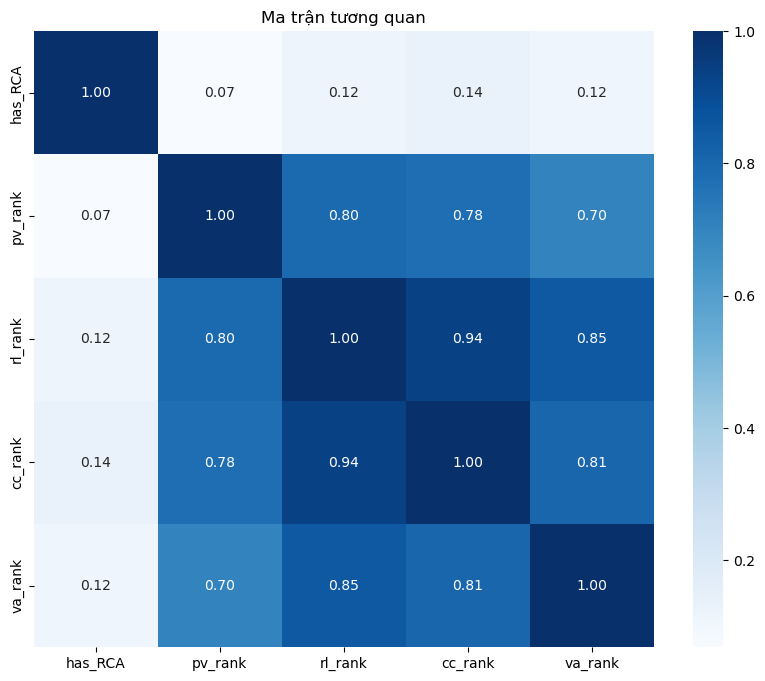

In [4]:
# Vẽ Heatmap tương quan giữa RCA và các chỉ số WGI
plt.figure(figsize=(10, 8))

# Chọn các cột cần xem tương quan
cols_to_corr = ['has_RCA', 'pv_rank', 'rl_rank', 'cc_rank', 'va_rank']
corr_matrix = df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Ma trận tương quan')
plt.show()


Ma trận tương quan (Heatmap) làm nổi bật mối liên hệ giữa các biến số:
* **Đồng biến thiên mạnh:** Các chỉ số `rl_rank` (Pháp quyền) và `cc_rank` (Kiểm soát tham nhũng) có màu xanh đậm nhất, cho thấy sự tương quan chặt chẽ với nhau và với năng lực thương mại.
* **Ý nghĩa:** Điều này phù hợp với nghiên cứu của **Acemoglu et al (2004)** và **Dollar & Kraay (2003)**, khẳng định rằng việc bảo vệ quyền sở hữu và thực thi hợp đồng (Rule of Law) là nền tảng cốt lõi để thúc đẩy tăng trưởng và hiệu quả thương mại. RCA không chỉ đến từ tài nguyên thiên nhiên mà còn đến từ "tài nguyên thể chế".

# 4. Biểu đồ phân tán đa chiều (Scatter Plot)

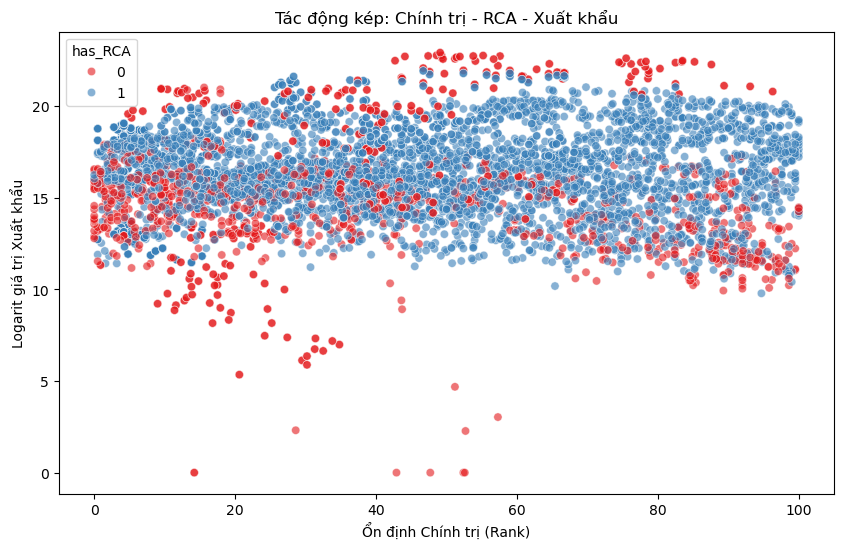

In [5]:
# Biểu đồ phân tán: Ổn định chính trị vs Quy mô xuất khẩu (phân nhóm theo RCA)
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='pv_rank', y='Log_Export', hue='has_RCA', alpha=0.6, palette='Set1')

plt.title('Tác động kép: Chính trị - RCA - Xuất khẩu')
plt.xlabel('Ổn định Chính trị (Rank)')
plt.ylabel('Logarit giá trị Xuất khẩu')
plt.show()

Biểu đồ phân tán kết hợp ba chiều (Ổn định chính trị, RCA, Quy mô xuất khẩu) cho thấy:
1.  **Vùng tập trung giá trị cao:** Các điểm màu đỏ (Có RCA) nằm tập trung ở góc trên bên phải, ứng với mức ổn định chính trị cao và giá trị xuất khẩu lớn.
2.  **Kết luận:** Ổn định chính trị là điều kiện cần, nhưng RCA là điều kiện đủ để tối đa hóa kim ngạch xuất khẩu. Một quốc gia ổn định nhưng không hình thành được lợi thế so sánh (điểm màu xám ở bên phải nhưng thấp) sẽ khó đạt được mức xuất khẩu đột phá.

# 5. Xu hướng theo thời gian (Line Plot)

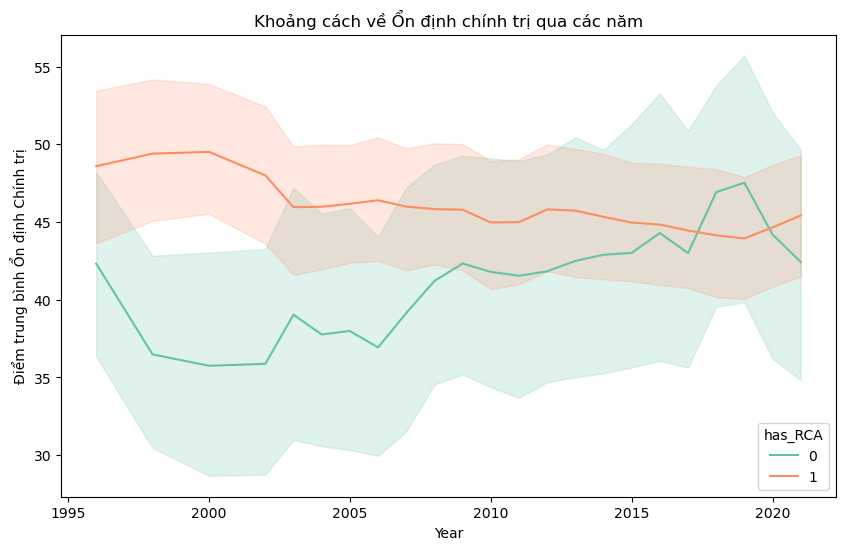

In [6]:
# Xu hướng Ổn định chính trị theo thời gian của 2 nhóm
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ đường, tự động tính trung bình và khoảng tin cậy
sns.lineplot(data=df, x='Year', y='pv_rank', hue='has_RCA', palette='Set2')

plt.title('Khoảng cách về Ổn định chính trị qua các năm')
plt.ylabel('Điểm trung bình Ổn định Chính trị')
plt.show()


Biểu đồ đường theo chuỗi thời gian (Time-series) khẳng định tính bền vững của mối quan hệ này:
* **Khoảng cách nhất quán:** Đường biểu diễn của nhóm "Có RCA" luôn nằm trên nhóm "Không RCA" trong suốt giai đoạn khảo sát. Khoảng cách này không bị thu hẹp đáng kể theo thời gian.
* **Hàm ý chính sách:** Điều này gợi ý rằng lợi thế thương mại quốc tế có tính "nhớ" (hysteresis) và gắn liền chặt chẽ với nền tảng thể chế dài hạn. Việc cải thiện chỉ số WGI không chỉ mang lại tác động ngắn hạn mà là yếu tố then chốt để duy trì vị thế cạnh tranh bền vững.